# Single Neuron Logistic Regression Model
In this notebook, I will implement a single neuron model alongside the gradient descent algorithm, in order to display Logistic Regression. We will be using the diabetes dataset

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("diabetes.csv")

In [16]:
df.iloc[:100]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
95,6,144,72,27,228,33.9,0.255,40,0
96,2,92,62,28,0,31.6,0.130,24,0
97,1,71,48,18,76,20.4,0.323,22,0
98,6,93,50,30,64,28.7,0.356,23,0


In [22]:
scaler = MinMaxScaler()
X = scaler.fit_transform(df[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness" ,"Insulin"]])
y = df.Outcome.values

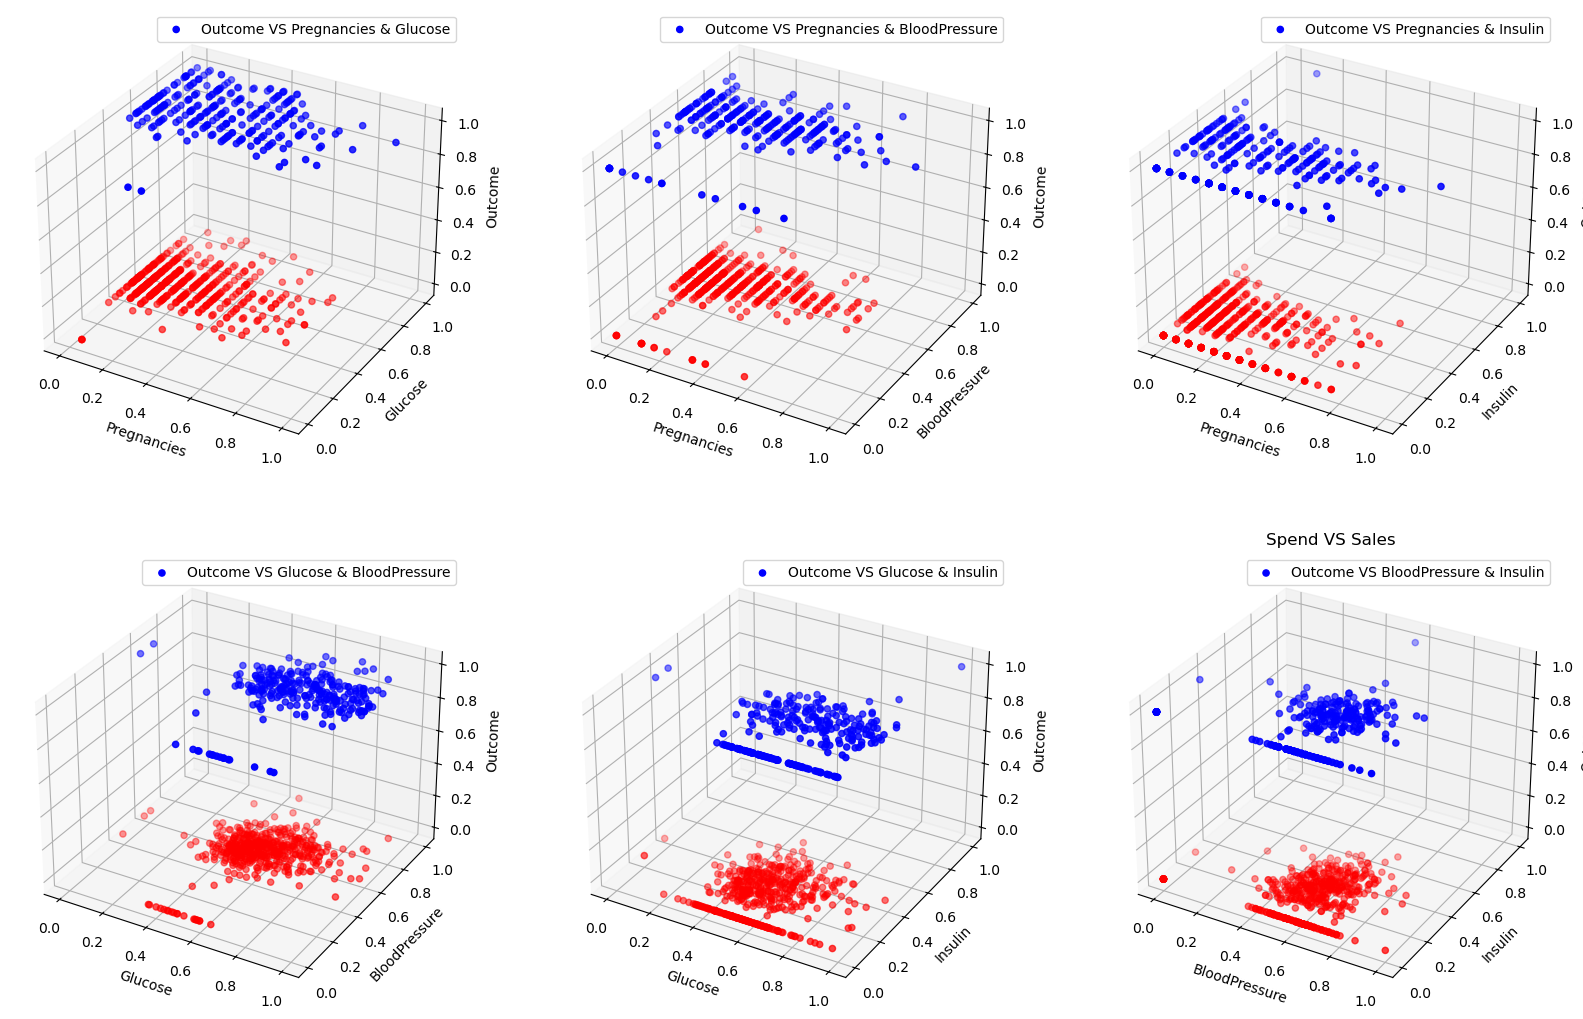

In [43]:
fig = plt.figure(figsize=(20,20))

attr_lst = ["Pregnancies", "Glucose", "BloodPressure", "Insulin"]
k = 0
colors = ["blue" if label == 1 else "red" for label in y]

for k, (i, j) in enumerate([(0,1), (0,2), (0,3), (1, 2), (1,3), (2,3)], start=1):
    ax = fig.add_subplot(3, 3, k, projection="3d")
    ax.scatter(X[:, i], X[:, j], y, c=colors, label="Outcome VS " + attr_lst[i] +" & "+ attr_lst[j])    
    ax.set_xlabel(attr_lst[i])
    ax.set_ylabel(attr_lst[j])
    ax.set_zlabel("Outcome")
    ax.legend()
    k += 1

#ax1 = fig.add_subpplot(112, projection="3d")
#ax.scatter(X[:, 0], X[:, 0], y, c="blue", label="Sales VS TV & Newspaper")
#ax.set_xlabel("TV Spending")
#ax.set_ylabel("Newspaper Spending")
#ax.set_zlabel("Sales")

#ax.legend()
plt.title("Spend VS Sales")
plt.show()

In [32]:
class SingleNeuron(object):
    """
    A class used to represent a Single Neuron

    Attributes
    ----------
    inputs : array
        an array of inputs to the perceptron
    outputs : array
        an array of expected outputs from the perceptron
    alpha : float
        the learning rate
    epochs : int
        the number of epochs to train

    Methods
    -------
    train()
        trains the perceptron for self.epoch iterations, to produce self.outputs from self.inputs.

    train_err_limit(self, percent_err, max_epochs=None)
        trains the perceptron until it reaches a certain percent_error rate or until max_epochs are reached.

    update_weights()
        updates the weights of the perceptron(self.w_) once using self.inputs and comparing with self.outputs.

    net_input(inputs):
        calculates the net input to the perceptron, by multiplying a given input with the weights and adding the bias.
    
    predict():
        calculates the output the perceptron produces for a given input.
    
    """
    
    def __init__(self, inputs, outputs, activation_function):
        if not isinstance(inputs, np.ndarray) or not isinstance(outputs, np.ndarray):
            raise TypeError("inputs and outputs must be NumPy arrays")
        if inputs.shape[0] != outputs.shape[0]:
            raise ValueError("inputs and outputs must have the same number of samples")
        if len(outputs.shape) != 1:
            raise ValueError("outputs must be a 1D array")
        
        self.activation_function = activation_function 
        self.inputs = inputs
        self.outputs = outputs
        self.w_ = np.random.rand(1+inputs.shape[1])
        self.errors_ = []
    
    def train(self, alpha = 0.005, epochs = 100):
        if not(isinstance(epochs, int)):
            raise TypeError("epochs must be an integer.")
        if epochs < 1:
            raise ValueError("Epochs must be less than 1")

        if not isinstance(alpha, float):
            raise TypeError("aplha must be a float")
        if not (0 < alpha <= 1):
            raise ValueError("alpha must be between 0 and 1")

        self.alpha = alpha
        self.epochs = epochs
        N = self.inputs.shape[0]

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(self.inputs, self.outputs):
                error = self.predict(xi) - target
                self.w_[:-1] -= self.alpha * error * xi
                self.w_[-1] -= self.alpha * error
                errors += 0.5 * (error ** 2)

            
            self.errors_.append(errors/N)
        return
    def predict(self, X):
        preactivation = np.dot(X, self.w_[:-1]) + self.w_[-1]
        return self.activation_function(preactivation)

In [50]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

node = SingleNeuron(X, y,  sigmoid)
y_pred = node.predict(X)

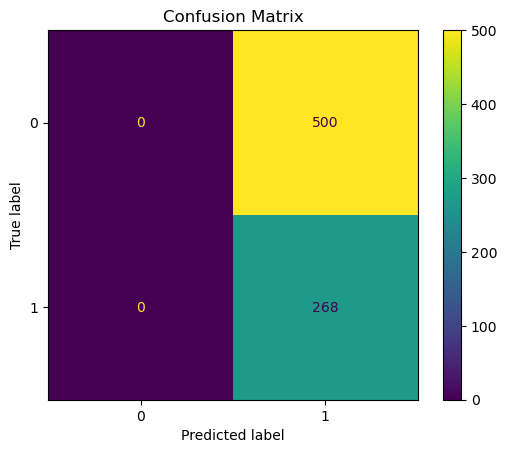

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_class = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y, y_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [52]:
node.train(epochs = 1000)
y_pred = node.predict(X)

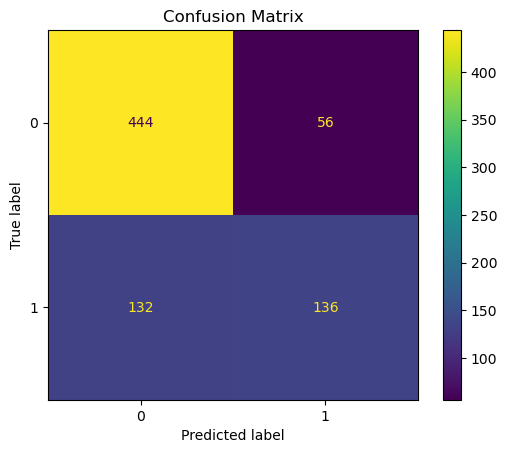

In [53]:
y_class = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y, y_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()